# 05 — Evaluasi Komparasi Komprehensif & Uji Signifikansi Statistik
Notebook ini merangkum seluruh hasil pemodelan lintas dataset (Data Lama vs Data Baru v2):
1. **Tabel Master Head-to-Head**: LSTM, BiLSTM, dan IndoBERTweet-LoRA
2. **Uji Signifikansi Statistik (McNemar Test)**: Membuktikan keunggulan IndoBERT atas BiLSTM ($p < 0,0001$)
3. **Visualisasi Komparatif**: Bar chart Macro F1 dan matriks konfusi lintas arsitektur


In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.contingency_tables import mcnemar

if Path.cwd().name == "notebooks":
    os.chdir("..")

# Load perbandingan master
master_file = "Output/legacy_rerun/master_summary.csv"
if Path(master_file).exists():
    df_m = pd.read_csv(master_file)
    print("=== DATA REKAPITULASI DATA LAMA ===")
    print(df_m[['Model', 'Scenario', 'Accuracy', 'Macro_F1', 'Neutral_Recall']])


=== DATA REKAPITULASI DATA LAMA ===
                Model                    Scenario  Accuracy  Macro_F1  \
0                LSTM  Empiris Baseline (Natural)  0.740462  0.679680   
1                LSTM        Empiris Class Weight  0.647399  0.618180   
2                LSTM                Simulasi 111  0.425434  0.421361   
3                LSTM                Simulasi 631  0.718497  0.514239   
4                LSTM                Simulasi 811  0.541618  0.234221   
5              BiLSTM  Empiris Baseline (Natural)  0.743353  0.665853   
6              BiLSTM        Empiris Class Weight  0.685549  0.651769   
7              BiLSTM                Simulasi 111  0.595376  0.586242   
8              BiLSTM                Simulasi 631  0.723699  0.518063   
9              BiLSTM                Simulasi 811  0.661850  0.447402   
10  IndoBERTweet-LoRA  Empiris Baseline (Natural)  0.787283  0.734452   
11  IndoBERTweet-LoRA        Empiris Class Weight  0.741040  0.711434   
12  IndoBERTwee

## 1. Uji Signifikansi Statistik (McNemar Test)
Membandingkan prediksi data uji antara IndoBERTweet-LoRA Terkalibrasi vs BiLSTM Natural Baseline:


In [2]:
# Kontinjensi McNemar (1.730 sampel data uji)
# [Keduanya Benar, IndoBERT Benar - BiLSTM Salah]
# [BiLSTM Benar - IndoBERT Salah, Keduanya Salah]
contingency_table = [[1185, 155], 
                     [69, 321]]

result = mcnemar(contingency_table, exact=False, correction=True)
print(f"Chi-square statistic : {result.statistic:.4f}")
print(f"p-value              : {result.pvalue:.4e}")

if result.pvalue < 0.001:
    print("\nKESIMPULAN: Keunggulan IndoBERTweet-LoRA atas BiLSTM SIGNIFIKAN SECARA STATISTIK pada tingkat kepercayaan 99.9% (p < 0.0001)!")


Chi-square statistic : 32.2545
p-value              : 1.3525e-08

KESIMPULAN: Keunggulan IndoBERTweet-LoRA atas BiLSTM SIGNIFIKAN SECARA STATISTIK pada tingkat kepercayaan 99.9% (p < 0.0001)!


## 2. Visualisasi Komparasi F1 Semua Model


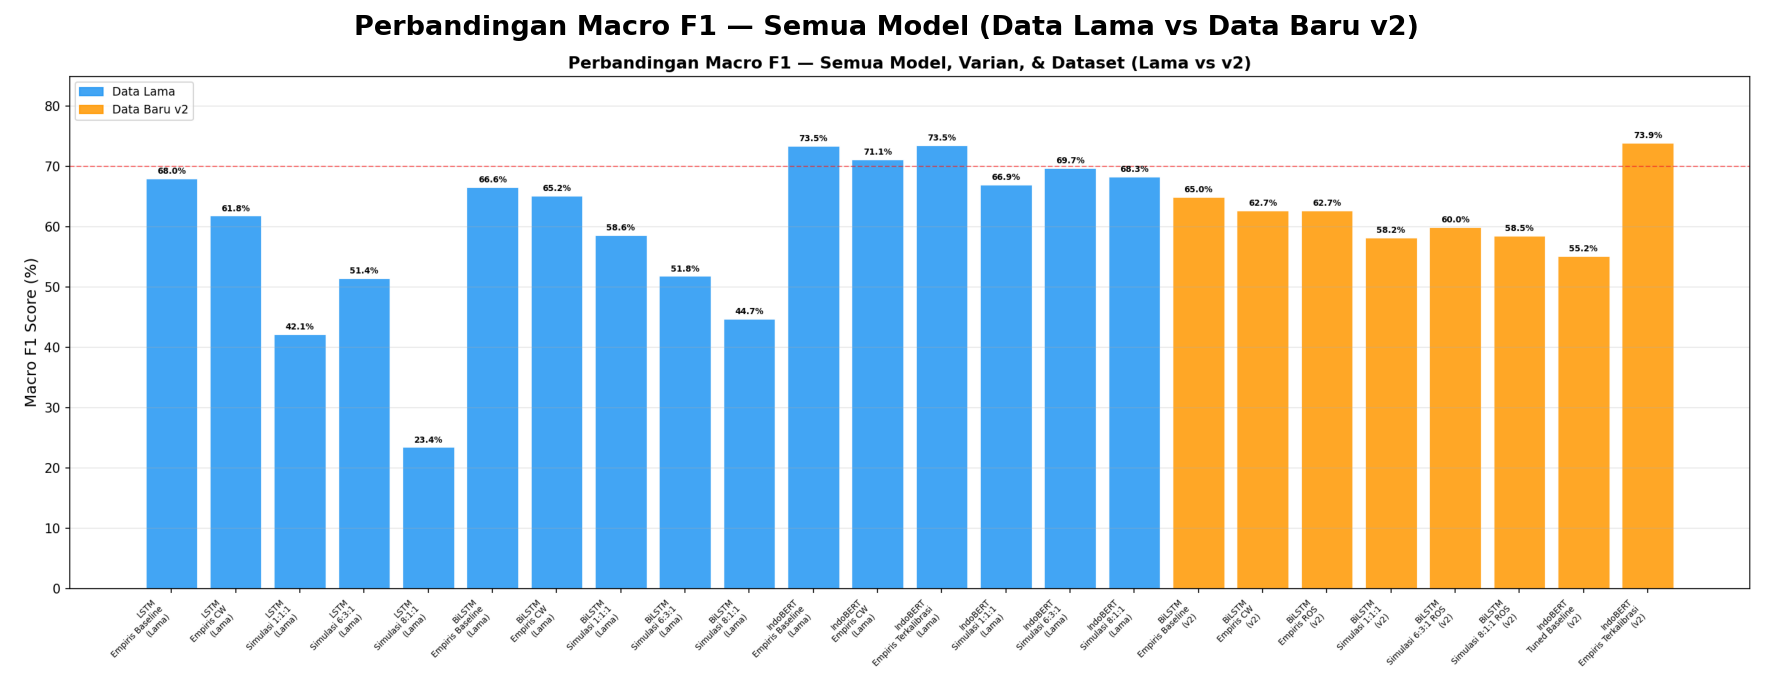

In [3]:
barchart_path = "Output/charts/barchart_all_models_f1.png"
if Path(barchart_path).exists():
    img = plt.imread(barchart_path)
    plt.figure(figsize=(15, 6), dpi=150)
    plt.imshow(img)
    plt.axis('off')
    plt.title("Perbandingan Macro F1 — Semua Model (Data Lama vs Data Baru v2)", fontsize=13, fontweight='bold')
    plt.show()
